In [ ]:
#Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates



In [ ]:
df = pd.read_csv("/content/retail_sales_dataset.csv")

In [ ]:
# Inspect the first few rows
df.head()



,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# Basic information
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
# Summary statistics
df.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
# Check for missing values
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
#Understanding the columns
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

**Basic Data Cleaning**

The data is basically clean at this point,no duplicates. The total amount is derived from Quantity * Price

**Questions to Explore**
1. How does customer age and gender influence purchasing behavior?
Here,we analyze how age and gender affect:

Quantity purchased

Total spending

Product category preferences



In [ ]:
# Spending by gender
print("Spending by Gender:")
print(df.groupby('Gender')['Total Amount'].agg(['mean', 'sum']))

# Create age groups
df['Age Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 50, 65], labels=['18-25', '26-35', '36-50', '51-65'])

# Spending by age group
print("\nSpending by Age Group:")
print(df.groupby('Age Group')['Total Amount'].agg(['mean', 'sum']))

# Gender and Product Category Preferences
print("\nGender & Product Category Preferences:")
print(df.groupby(['Gender', 'Product Category'])['Total Amount'].sum().unstack().fillna(0))



Spending by Gender:
              mean     sum
Gender                    
Female  456.549020  232840
Male    455.428571  223160

Spending by Age Group:
                 mean     sum
Age Group                    
18-25      495.506757   73335
26-35      480.390244   98480
36-50      446.198083  139660
51-65      425.910543  133310

Gender & Product Category Preferences:
Product Category  Beauty  Clothing  Electronics
Gender                                         
Female             74830     81275        76735
Male               68685     74305        80170


/tmp/ipykernel_1917/3169928126.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age Group')['Total Amount'].agg(['mean', 'sum']))


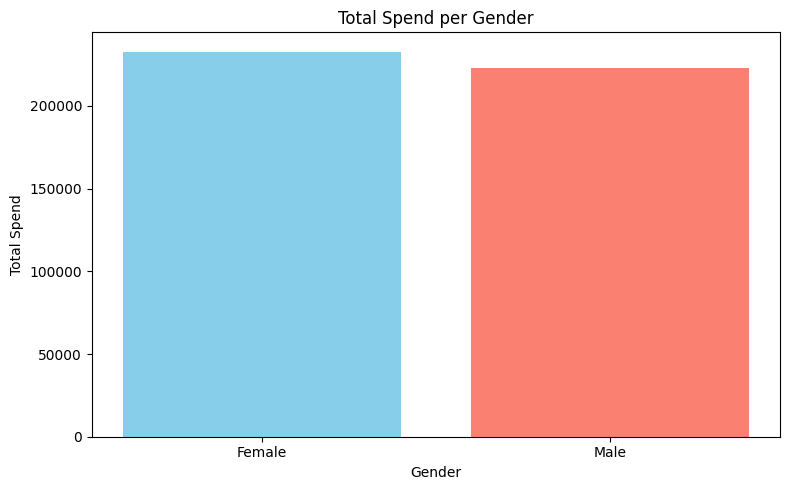

In [ ]:
# Group by gender and calculate total or average spend
spend_by_gender = df.groupby('Gender')['Total Amount'].sum().reset_index()  # use .mean() for average

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(spend_by_gender['Gender'], spend_by_gender['Total Amount'], color=['skyblue', 'salmon'])
plt.title('Total Spend per Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/1469480020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Total Amount', palette='pastel')


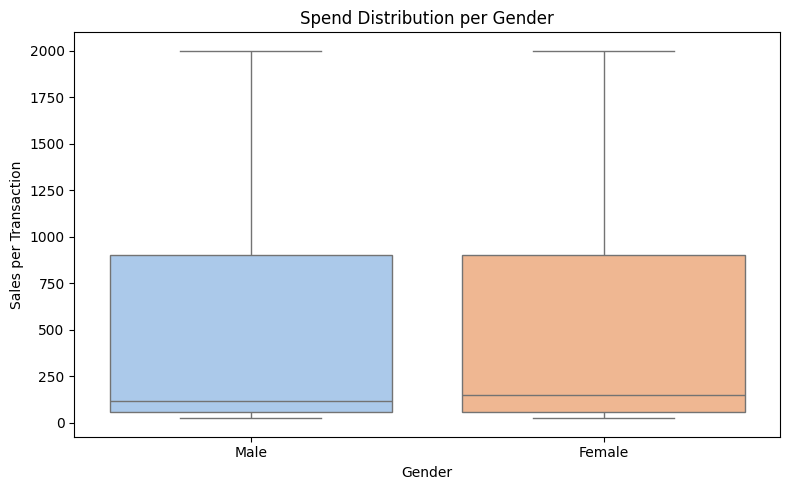

In [ ]:
# Boxplot of spend per transaction grouped by gender
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Total Amount', palette='pastel')
plt.title('Spend Distribution per Gender')
plt.xlabel('Gender')
plt.ylabel('Sales per Transaction')
plt.tight_layout()
plt.show()

<ipython-input-8-1754435711>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='Total Amount', data=df, palette='Set2')


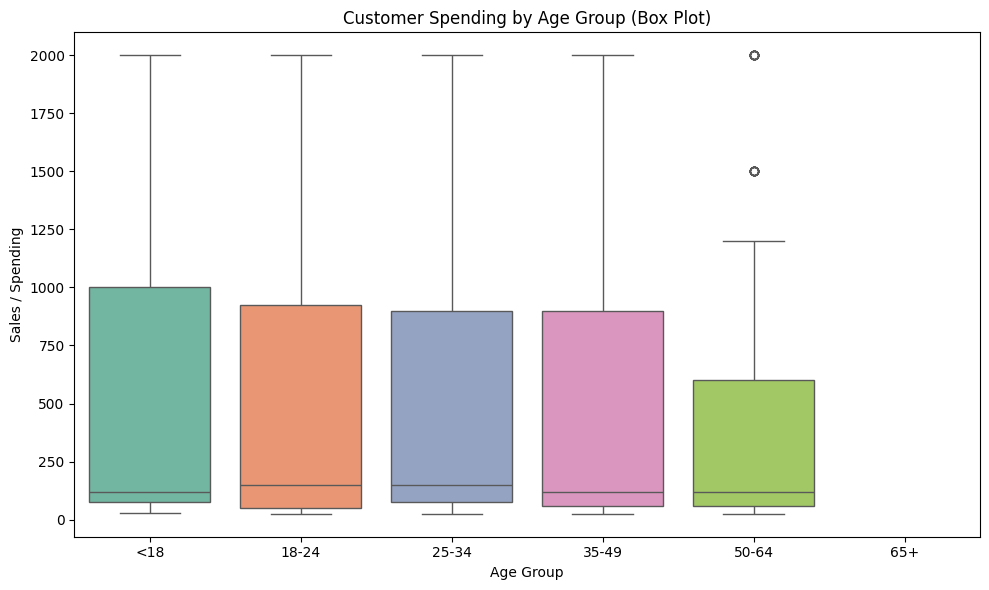

In [ ]:
# Optional: create age groups (bins)
bins = [0, 18, 25, 35, 50, 65, 100]
labels = ['<18', '18-24', '25-34', '35-49', '50-64', '65+']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# --- BOX PLOT: Spending by Age Group ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='Total Amount', data=df, palette='Set2')
plt.title('Customer Spending by Age Group (Box Plot)')
plt.xlabel('Age Group')
plt.ylabel('Sales / Spending')
plt.tight_layout()
plt.show()

Observation

Here, I observed that (25-34) is the median spending group with young professionals.(18-49) group represents the largest spending group.Also, from
50-64,we have some big spenders or outliers.Finally,we have the Below 18
possibly the dependent shoppers



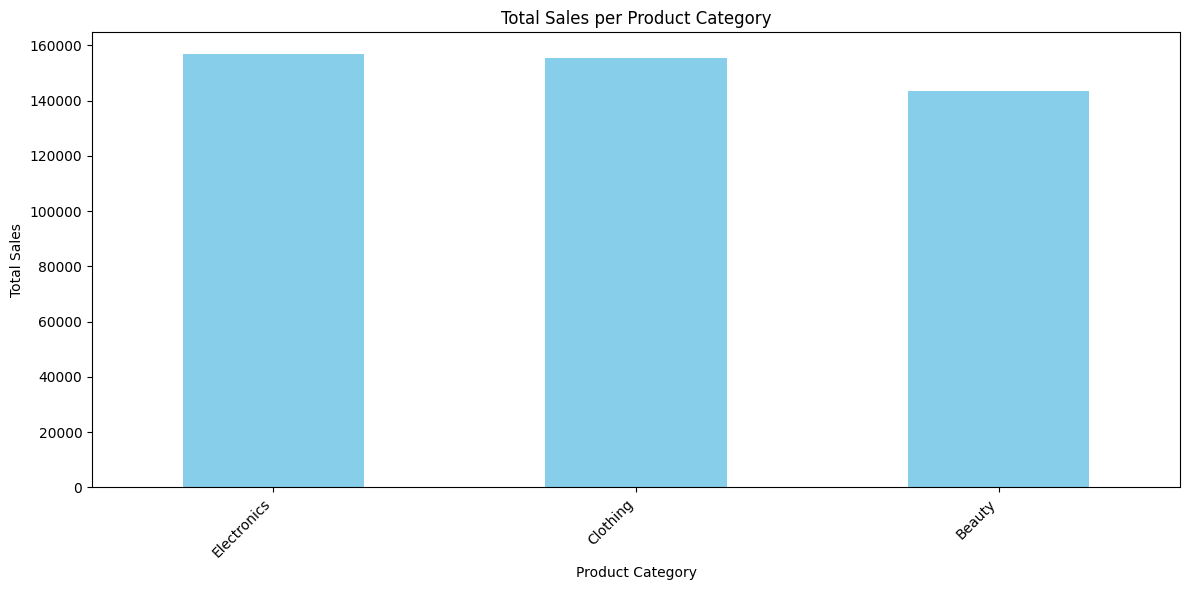

In [ ]:
# Group by product and sum the sales
product_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
product_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

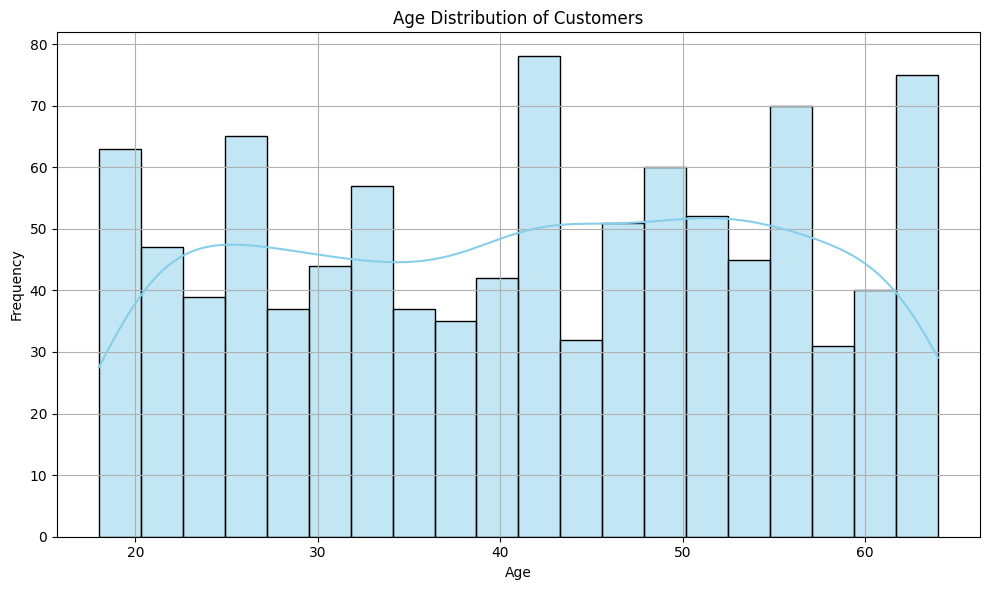

In [ ]:
# Plotting the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='skyblue', edgecolor='black')

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

From the data above, we can see that the mean and sum total of female is slightly higher than male. When we look at the age distribution the 35-49 age group has the highest buys, closely followed by 50-64 and then older ages 60 and above, we have few outliers and consistent spending habits. Finally, Females bought more beauty and clothing products than males. However, more males bought electronics than females.

2. Are there discernible patterns in sales across different time periods?
Here, we want to identify sales trends by month, day of week, season.



In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()

# Monthly sales
df.groupby('Month')['Total Amount'].sum()

# Daily sales patterns
df.groupby('DayOfWeek')['Total Amount'].sum()


,Total Amount
DayOfWeek,
Friday,66290
Monday,70250
Saturday,78815
Sunday,58600
Thursday,53835
Tuesday,69440
Wednesday,58770


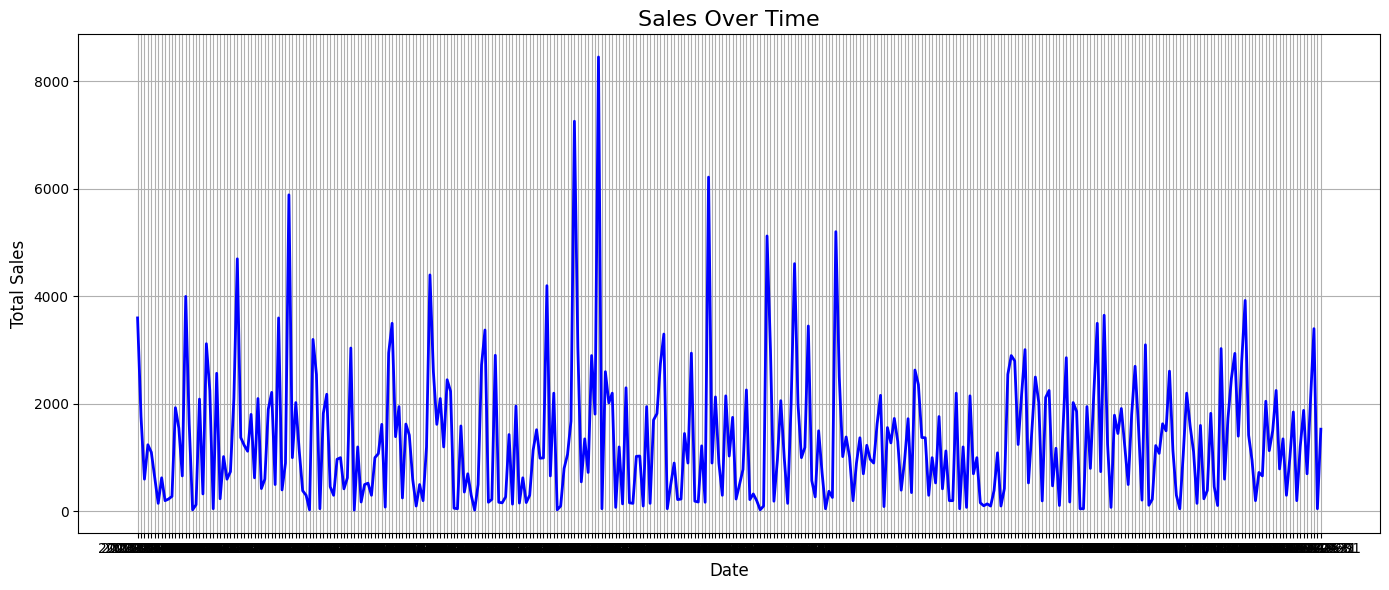

In [ ]:
daily_sales = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(14, 6))  # Optional: Resize the figure
plt.plot(daily_sales.index, daily_sales.values, color='blue', linewidth=2)

# Add titles and labels
plt.title("Sales Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

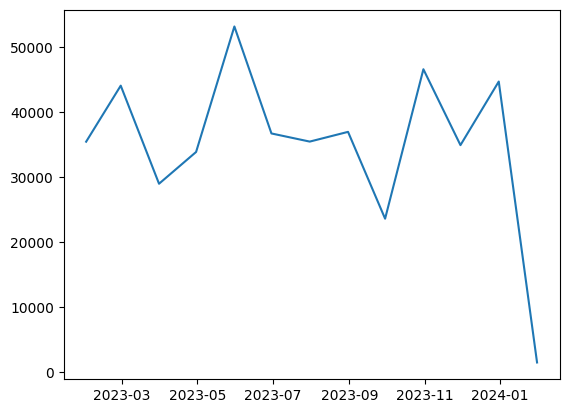

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.set_index('Date')['Total Amount'].resample('ME').sum()
plt.plot(monthly_sales.index, monthly_sales.values)

From the above,we see the daily sales and monthly sales over time and its clear that peak exist between 2023-05 and 2023-11

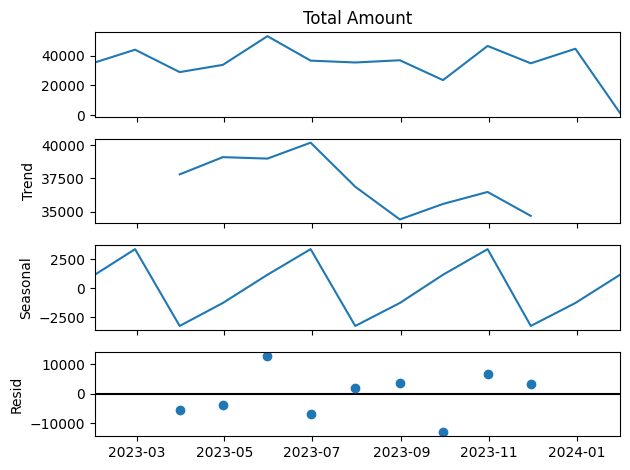

In [ ]:
#Time Series Decomposition
decomposition = seasonal_decompose(monthly_sales, model='additive', period=4)
decomposition.plot()
plt.show()


 Components of Decomposition:

1. Observed

It shows the raw trend, seasonality, and random variations.

You'll notice peaks and drops that reflect customer buying behavior over time.


2. Trend

The trend line isn't increasing.

It's  declining, it indicates stagnant or dropping sales, possibly requiring marketing or product interventions.





3. Seasonality

This shows repeating patterns at regular intervals.

You might see recurring peaks just before December (holiday season), or lows in February, which could reflect real-world buying patterns.

There is strong seasonality trend which suggests that the  business is affected by holidays, weather or cycles.


We see sales  spike in May and October, those could be high-impact periods worth planning promotions around.



4. Residual (Noise)

This captures what's left over after removing the trend and seasonal effects — essentially random fluctuations

Here, residuals  are small and random this means that the noise are minimal.




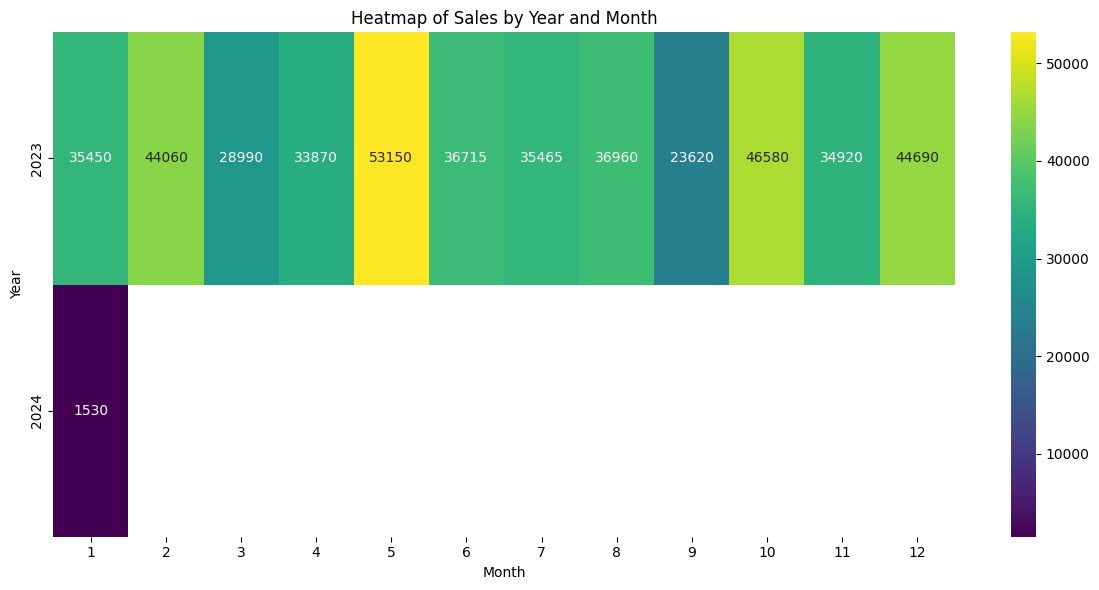

In [ ]:
# Convert datetime column
df['datetime'] = pd.to_datetime(df['Date'])  # Replace with your datetime column

# Extract month and year
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

# Create a pivot table: rows = year, columns = month, values = sum of sales
pivot = pd.pivot_table(df,
                       index='year',
                       columns='month',
                       values='Total Amount',  # Replace with your sales column name
                       aggfunc='sum')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='viridis')
plt.title('Heatmap of Sales by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

 3. Which product categories hold the highest appeal among customers?
Here,we Find the most popular categories by quantity and revenue.


In [ ]:
# By quantity sold
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)



,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


In [ ]:
# By total revenue
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)


,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


4. What is the relationship between age, spending, and product preferences?
Here,we are interested in seeing how age relates to product spending.



In [ ]:
# Age vs. spending
df.groupby('Age')['Total Amount'].mean()

# Age group vs. product preferences
df.groupby(['Age Group', 'Product Category'])['Total Amount'].sum().unstack().fillna(0)


<ipython-input-30-1665047667>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age Group', 'Product Category'])['Total Amount'].sum().unstack().fillna(0)


Product Category,Beauty,Clothing,Electronics
Age Group,,,
18-25,26320,22425,24590
26-35,31240,39975,27265
36-50,49110,42975,47575
51-65,31885,46120,55305


5. How do customers adapt their shopping habits during seasonal trends?
Our goal here is to understand if certain product categories are more popular in certain months.


In [ ]:
# Monthly sales per category
df.groupby(['Month', 'Product Category'])['Total Amount'].sum().unstack().fillna(0)


Product Category,Beauty,Clothing,Electronics
Month,,,
April,11905,13940,8025
August,9790,12455,14715
December,12400,12070,20220
February,14035,14560,15465
January,13930,13125,9925
July,16090,8250,11125
June,10995,10170,15550
March,10545,15065,3380
May,12450,17455,23245


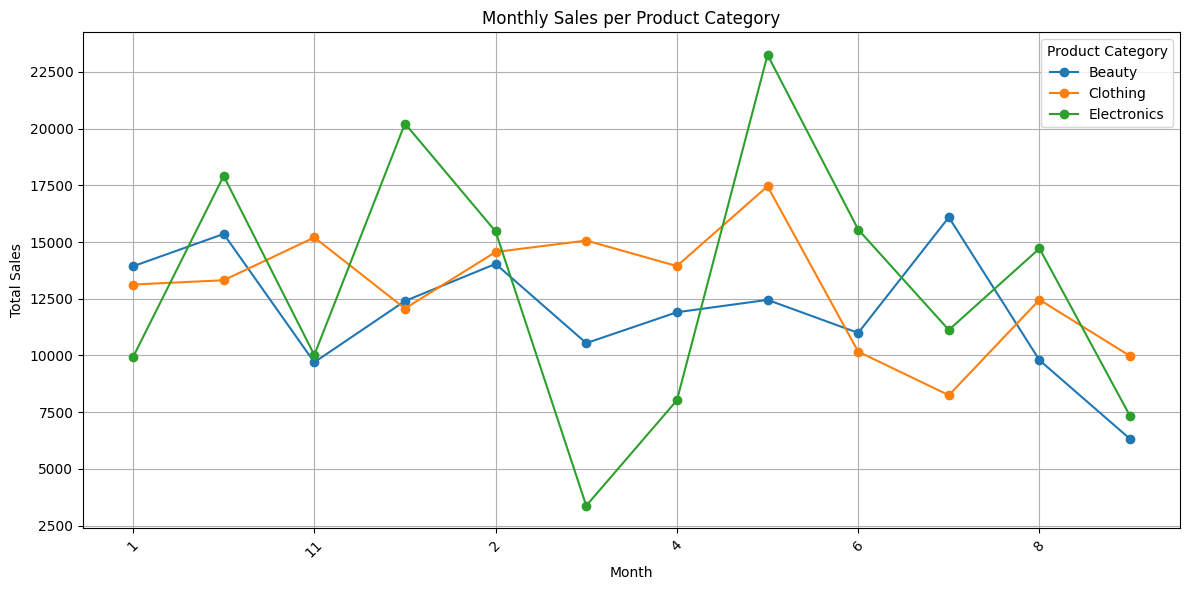

In [ ]:
# Ensure 'month' is treated as a categorical variable for plotting if needed
df['month'] = df['month'].astype(str)

# Group and pivot: Monthly sales per product category
monthly_sales = df.groupby(['month', 'Product Category'])['Total Amount'].sum().unstack().fillna(0)

# --- Option 1: Line Plot (Trends Over Time) ---
monthly_sales.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Monthly Sales per Product Category')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Product Category')
plt.show()

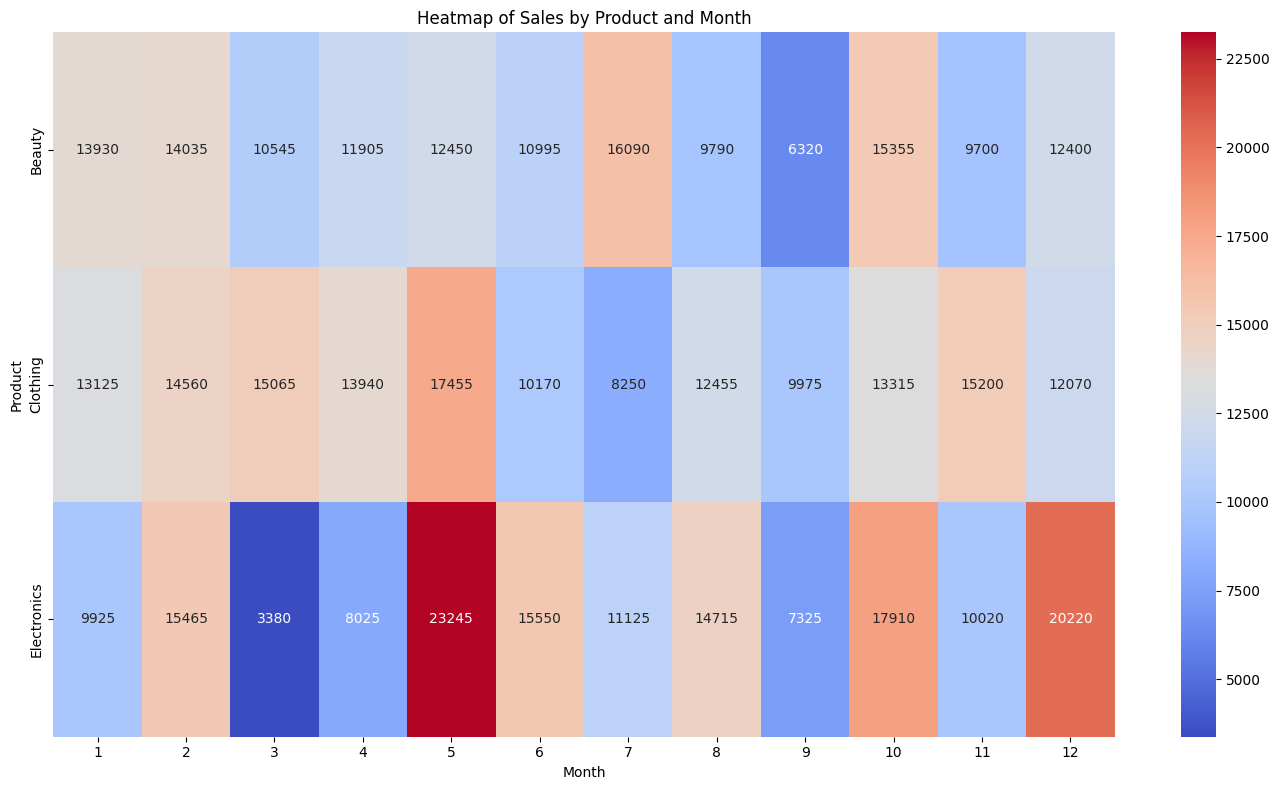

In [ ]:
# Extract month
df['month'] = df['datetime'].dt.month

# Create a pivot table: rows = product, columns = month, values = sum of sales
pivot = pd.pivot_table(df,
                       index='Product Category',
                       columns='month',
                       values='Total Amount',
                       aggfunc='sum',
                       fill_value=0)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title('Heatmap of Sales by Product and Month')
plt.xlabel('Month')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In the above, we see a dominance of electronics over other categories of goods sold.

6. Are there distinct purchasing behaviors based on the number of items bought per transaction?
The idea is to segment transactions by quantity and analyze spending.


In [ ]:
# Quantity distribution
df['Quantity'].describe()

# Spending by quantity group
df['Qty Group'] = pd.cut(df['Quantity'], bins=[0, 1, 3, 10], labels=['Single Item', 'Few Items', 'Bulk Purchase'])
df.groupby('Qty Group')['Total Amount'].agg(['mean', 'sum'])


<ipython-input-28-1901767203>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Qty Group')['Total Amount'].agg(['mean', 'sum'])


,mean,sum
Qty Group,,
Single Item,177.094862,44805
Few Items,465.568182,225335
Bulk Purchase,706.692015,185860


count    1000.000000
mean        2.514000
std         1.132734
min         1.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Quantity, dtype: float64
       Qty Group        mean     sum  count
0    Single Item  177.094862   44805    253
1      Few Items  465.568182  225335    484
2  Bulk Purchase  706.692015  185860    263


<ipython-input-16-4077529824>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qty_spending = df.groupby('Qty Group')['Total Amount'].agg(['mean', 'sum', 'count']).reset_index()
<ipython-input-16-4077529824>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=qty_spending, x='Qty Group', y='sum', palette='viridis')


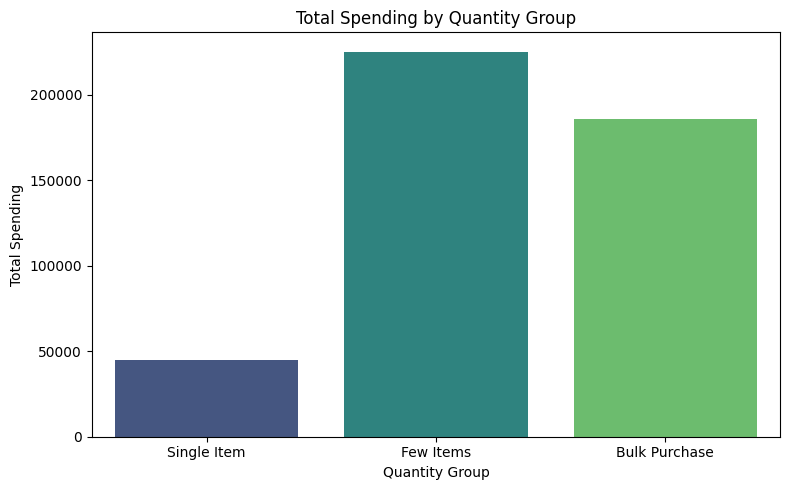

In [ ]:
# 1. Quantity distribution summary
print(df['Quantity'].describe())

# 2. Create quantity group
df['Qty Group'] = pd.cut(df['Quantity'],
                         bins=[0, 1, 3, 10],
                         labels=['Single Item', 'Few Items', 'Bulk Purchase'],
                         include_lowest=True)

# 3. Spending analysis by quantity group
qty_spending = df.groupby('Qty Group')['Total Amount'].agg(['mean', 'sum', 'count']).reset_index()
print(qty_spending)

# 4. Optional: Bar plot for total spending per quantity group
plt.figure(figsize=(8, 5))
sns.barplot(data=qty_spending, x='Qty Group', y='sum', palette='viridis')
plt.title('Total Spending by Quantity Group')
plt.xlabel('Quantity Group')
plt.ylabel('Total Spending')
plt.tight_layout()
plt.show()


In [ ]:
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()


7. What insights can be gleaned from the distribution of product prices within each category?
what are the  price range per product category.

In [ ]:
df.groupby('Product Category')['Price per Unit'].describe()


,count,mean,std,min,25%,50%,75%,max
Product Category,,,,,,,,
Beauty,307.0,184.055375,194.929399,25.0,30.0,50.0,300.0,500.0
Clothing,351.0,174.287749,186.017065,25.0,30.0,50.0,300.0,500.0
Electronics,342.0,181.900585,189.049673,25.0,30.0,50.0,300.0,500.0


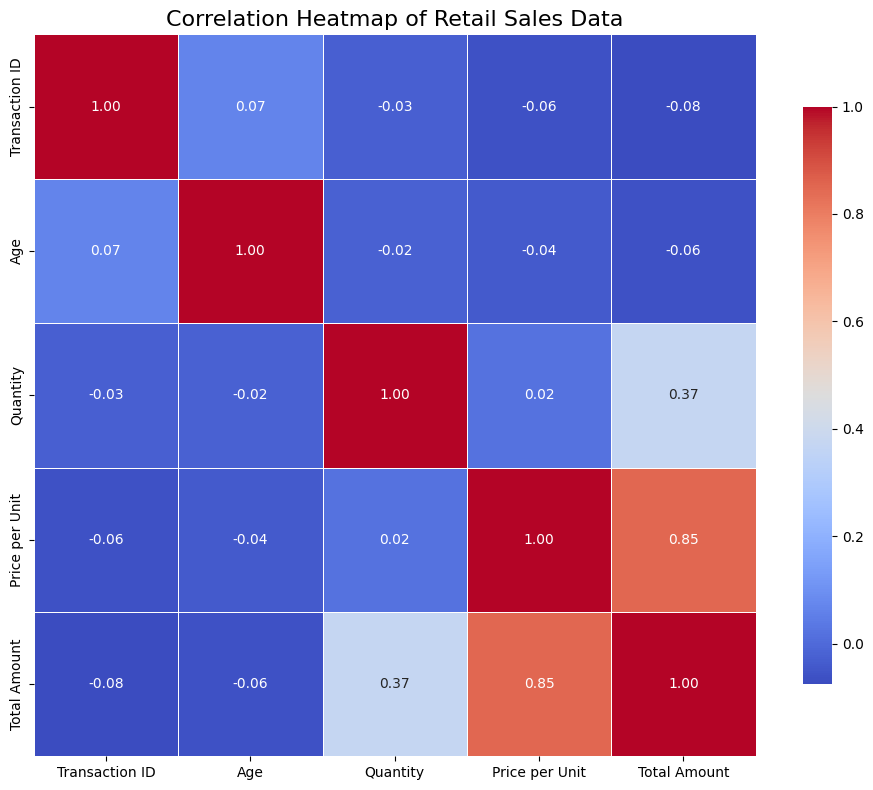

In [ ]:
# Step 2: Keep only numerical columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Step 3: Compute correlation matrix
corr_matrix = numeric_df.corr()

# Step 4: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,         # Show correlation values
            fmt='.2f',          # Decimal places
            cmap='coolwarm',    # Color scheme
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})  # Color bar styling

plt.title('Correlation Heatmap of Retail Sales Data', fontsize=16)
plt.tight_layout()
plt.show()


**OBSERVATIONS**

1.Central Tendency:
All categories have a median (50%) of 50, meaning most products are priced moderately.

The means are higher than the medians in all categories (174–184), indicating right-skewed distributions — i.e., some high-priced items are pulling the average up.

2.Price Range:
The minimum price is consistently 25, and maximum price is 500 across all categories, suggesting standardized price caps.

The 25th percentile (Q1) is 30 and 75th percentile (Q3) is 300 — a wide IQR (interquartile range) that shows diverse pricing tiers.

3.Variability
There is a high price variation within each category.

This means each category likely includes both budget and premium products.





🧠 **Overall Key Insights**

1. Customer Demographics & Purchasing Behavior

Age Groups 25–34 and 35–49 are the highest spenders, especially in beauty and clothing categories.

Females spent more overall and dominate purchases in beauty and clothing.

Males are the dominant buyers of electronics.


2. Time-Based Sales Trends

Sales peaked in May and October, possibly indicating seasonal campaigns or promotions.

Sales dip around February and early Q1, suggesting lower customer activity during that time.

Decomposition analysis revealed a declining trend, although seasonality remains strong.


3. Product Category Performance

Electronics lead in both revenue and popularity.

Beauty and clothing perform well among younger customers, especially females.

Wide price range and variability in all product categories (₦25 to ₦500), suggesting tiered product positioning.


4. Shopping Behavior & Quantity

Majority of purchases fall into the "Few Items" group (2–3 items).

Bulk purchases account for the highest average spending per transaction.

Strong correlation between quantity and total amount spent.


5. Seasonal & Monthly Product Preferences

Certain product categories (e.g., electronics, clothing) experience monthly variation in demand.

Heatmap patterns reveal clear seasonality — indicating promotional windows and planning opportunities.


6. Price Distribution

All categories are right-skewed, meaning a few high-priced items elevate the average price.

Significant price variability offers room for both luxury and budget customer segments.



 **Recommendations**

🛍 Product Strategy

Diversify pricing further within each category to cater to low- and high-income brackets.

Introduce or promote bundled deals for the "Few Items" group to encourage upselling.

Consider subscription models or loyalty rewards for high-spending age groups (25–49).


📅 Marketing & Promotions

Concentrate major promotions in May and October, where natural sales peaks exist.

Create seasonal campaigns targeting low-sales periods (e.g., February) to stabilize revenue flow.

Use personalized offers for males (electronics) and females (beauty/clothing) to boost engagement.


📊 Data-Driven Planning

Monitor trends in product category performance monthly to adapt stock and promotions accordingly.

Leverage the heatmap patterns for predictive planning, especially around high-demand months.


👥 Customer Segmentation

Tailor marketing messaging based on gender and age group insights.

Engage the 18–24 group with more affordable options to grow their spending behavior over time.


📈 Strategic Outlook

The downward sales trend warrants action: consider customer re-engagement strategies, better inventory optimization, and cross-selling initiatives to reverse the slope.

Use residual analysis (minimal noise) to focus on predictable sales factors rather than anomalies.

